# Road Traffic Accident Data

### 01 Data Preprocessing
 1. Understand the Data
 2. Handle Missing Values
 3. Handle Duplicates
 4. Handle Outliers
 5. Handle Incorrect or Inconsistent Data
 6. Encode Categorical Variables
 7. Save Processed Data

### 1. Understand the Data
* Load the dataset (CSV, Excel, JSON, SQL, etc.).
* Check the structure of the dataset (rows, columns, data types,statis etc).

In [1]:
# Import all the required libraries
import pandas as pd
import numpy as np

In [2]:
# I have data in 2 files so we will combine and use it.
df1 = pd.read_csv(r"RTA Dataset.csv")
df2 = pd.read_csv(r"RTADatasetE1.csv")

In [3]:
df1.shape , df2.shape

((12316, 32), (2889, 30))

In [4]:
df1.columns.difference(df2.columns)

Index(['Number_of_casualties', 'Number_of_vehicles_involved'], dtype='object')

In [5]:
df = pd.concat([df1,df2],axis =0)


In [6]:
df.shape

(15205, 32)

In [7]:
df_copy = df.copy()

In [8]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15205 entries, 0 to 2888
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Time                         15205 non-null  object 
 1   Day_of_week                  15205 non-null  object 
 2   Age_band_of_driver           15205 non-null  object 
 3   Sex_of_driver                15205 non-null  object 
 4   Educational_level            14464 non-null  object 
 5   Vehicle_driver_relation      14626 non-null  object 
 6   Driving_experience           14376 non-null  object 
 7   Type_of_vehicle              14255 non-null  object 
 8   Owner_of_vehicle             14723 non-null  object 
 9   Service_year_of_vehicle      11277 non-null  object 
 10  Defect_of_vehicle            10778 non-null  object 
 11  Area_accident_occured        14966 non-null  object 
 12  Lanes_or_Medians             14820 non-null  object 
 13  Road_allignment       

In [10]:
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [11]:
df.columns

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [12]:
df.columns = map(lambda x: x.strip().lower(), df.columns)

In [13]:
df.columns

Index(['time', 'day_of_week', 'age_band_of_driver', 'sex_of_driver',
       'educational_level', 'vehicle_driver_relation', 'driving_experience',
       'type_of_vehicle', 'owner_of_vehicle', 'service_year_of_vehicle',
       'defect_of_vehicle', 'area_accident_occured', 'lanes_or_medians',
       'road_allignment', 'types_of_junction', 'road_surface_type',
       'road_surface_conditions', 'light_conditions', 'weather_conditions',
       'type_of_collision', 'number_of_vehicles_involved',
       'number_of_casualties', 'vehicle_movement', 'casualty_class',
       'sex_of_casualty', 'age_band_of_casualty', 'casualty_severity',
       'work_of_casuality', 'fitness_of_casuality', 'pedestrian_movement',
       'cause_of_accident', 'accident_severity'],
      dtype='object')

In [14]:
df.nunique()

,0
time,1074
day_of_week,7
age_band_of_driver,5
sex_of_driver,3
educational_level,7
vehicle_driver_relation,4
driving_experience,7
type_of_vehicle,17
owner_of_vehicle,4
service_year_of_vehicle,6


In [15]:
df['day_of_week'].value_counts()

,count
day_of_week,
Friday,2517
Thursday,2294
Wednesday,2239
Tuesday,2184
Saturday,2105
Monday,2066
Sunday,1800


In [16]:
df['cause_of_accident'].value_counts()

,count
cause_of_accident,
No distancing,2822
Changing lane to the right,2232
Changing lane to the left,1783
Driving carelessly,1739
No priority to vehicle,1484
Moving Backward,1405
No priority to pedestrian,881
Other,554
Overtaking,527


In [17]:
df.groupby('accident_severity').size()

,0
accident_severity,
Fatal injury,189
Serious Injury,2135
Slight Injury,12881


### 2.Handle Missing Values
* Identify missing values (df.isnull().sum()).
* Decide how to handle them:
* Remove rows/columns if missing values are too many.
* Impute values using mean, median, mode, or predictive modeling.



In [18]:
df.isnull().sum()

,0
time,0
day_of_week,0
age_band_of_driver,0
sex_of_driver,0
educational_level,741
vehicle_driver_relation,579
driving_experience,829
type_of_vehicle,950
owner_of_vehicle,482
service_year_of_vehicle,3928


In [19]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')

for col in df.columns:
  df[col] = imputer.fit_transform(df[col].values.reshape(-1, 1))[:, 0]


In [20]:
df.isnull().sum()

,0
time,0
day_of_week,0
age_band_of_driver,0
sex_of_driver,0
educational_level,0
vehicle_driver_relation,0
driving_experience,0
type_of_vehicle,0
owner_of_vehicle,0
service_year_of_vehicle,0


### 3. Handle Duplicates
* Check for duplicate rows ```df.duplicated().sum()```
* Remove duplicates if necessary `df.drop_duplicates()`.

In [21]:
df.duplicated().sum()

np.int64(0)

### 4. Handle Outliers
* Use boxplots, histograms, or IQR (Interquartile Range) method to detect outliers.
* Remove or transform outliers if they negatively impact the model.
##### Outlier Detection methods
* 1.Sorting method
* 2.Interquartile Range (IQR)
* 3.Using visualizations
* 4.Statistical outlier detection
* 5.Density-Based Spatial Clustering of Applications with Noise (DBSCAN

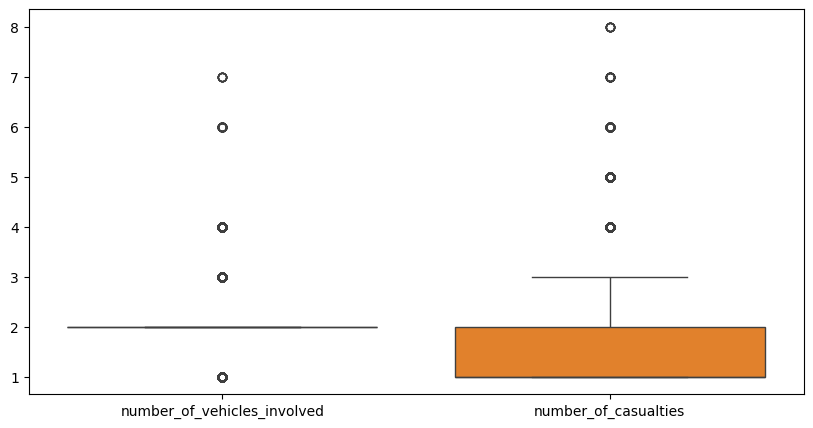

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.boxplot(df)
plt.show()

In [23]:
df.head()

,time,day_of_week,age_band_of_driver,sex_of_driver,educational_level,vehicle_driver_relation,driving_experience,type_of_vehicle,owner_of_vehicle,service_year_of_vehicle,...,vehicle_movement,casualty_class,sex_of_casualty,age_band_of_casualty,casualty_severity,work_of_casuality,fitness_of_casuality,pedestrian_movement,cause_of_accident,accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Unknown,...,Going straight,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the left,Serious Injury
3,01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Unknown,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,5-10yrs,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury


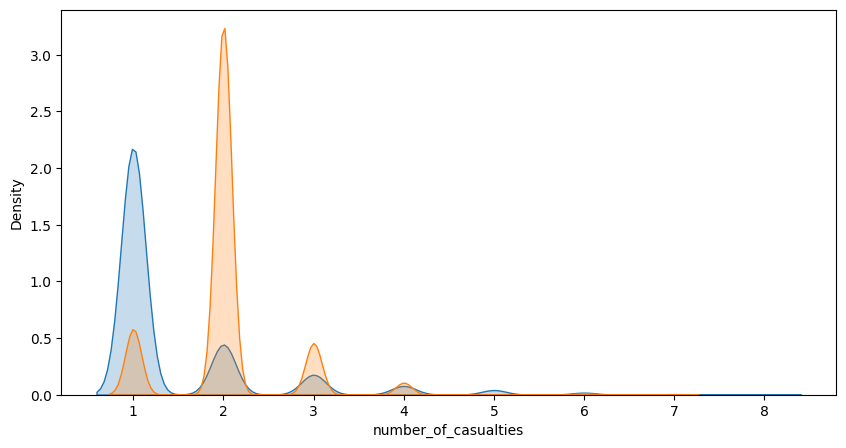

In [24]:
plt.figure(figsize=(10,5))
sns.kdeplot(df['number_of_casualties'],fill=True)
sns.kdeplot(df['number_of_vehicles_involved'],fill=True)
plt.show()


In [25]:
df['number_of_casualties'].mean()

np.float64(1.4439986846432096)

In [26]:
df['area_accident_occured'].value_counts()

,count
area_accident_occured,
Other,5023
Office areas,4114
Residential areas,2584
Church areas,1373
Industrial areas,572
School areas,519
Recreational areas,327
Outside rural areas,288
Hospital areas,152


In [27]:
df['casualty_severity'].value_counts()

,count
casualty_severity,
3,7076
na,4443
3,2724
2,771
2,159
1,26
1,6


In [28]:
df.dtypes

,0
time,object
day_of_week,object
age_band_of_driver,object
sex_of_driver,object
educational_level,object
vehicle_driver_relation,object
driving_experience,object
type_of_vehicle,object
owner_of_vehicle,object
service_year_of_vehicle,object


### 5. Handle Incorrect or Inconsistent Data

In [29]:
df['time'] = pd.to_datetime(df['time'])


/tmp/ipykernel_1770/2454786871.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time'] = pd.to_datetime(df['time'])


In [30]:
df.head()

,time,day_of_week,age_band_of_driver,sex_of_driver,educational_level,vehicle_driver_relation,driving_experience,type_of_vehicle,owner_of_vehicle,service_year_of_vehicle,...,vehicle_movement,casualty_class,sex_of_casualty,age_band_of_casualty,casualty_severity,work_of_casuality,fitness_of_casuality,pedestrian_movement,cause_of_accident,accident_severity
0,2026-04-15 17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,Moving Backward,Slight Injury
1,2026-04-15 17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury
2,2026-04-15 17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Unknown,...,Going straight,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the left,Serious Injury
3,2026-04-15 01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Unknown,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,2026-04-15 01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,5-10yrs,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury


### 7.Save the preprocessed data

In [31]:
df.to_csv('processed_data.csv', index=False)

In [32]:
import pandas as pd

df = pd.read_csv("processed_data.csv")

# Loop through all columns
for col in df.columns:
    print(f"\n🔹 Column: {col}")
    print(df[col].unique())


🔹 Column: time
['2026-04-15 17:02:00' '2026-04-15 01:06:00' '2026-04-15 14:15:00' ...
 '2026-04-15 07:24:00' '2026-04-15 19:18:00' '2026-04-15 02:47:00']

🔹 Column: day_of_week
['Monday' 'Sunday' 'Friday' 'Wednesday' 'Saturday' 'Thursday' 'Tuesday']

🔹 Column: age_band_of_driver
['18-30' '31-50' 'Under 18' 'Over 51' 'Unknown']

🔹 Column: sex_of_driver
['Male' 'Female' 'Unknown']

🔹 Column: educational_level
['Above high school' 'Junior high school' 'Elementary school'
 'High school' 'Unknown' 'Illiterate' 'Writing & reading']

🔹 Column: vehicle_driver_relation
['Employee' 'Unknown' 'Owner' 'Other']

🔹 Column: driving_experience
['1-2yr' 'Above 10yr' '5-10yr' '2-5yr' 'No Licence' 'Below 1yr' 'unknown']

🔹 Column: type_of_vehicle
['Automobile' 'Public (> 45 seats)' 'Lorry (41?100Q)'
 'Public (13?45 seats)' 'Lorry (11?40Q)' 'Long lorry' 'Public (12 seats)'
 'Taxi' 'Pick up upto 10Q' 'Stationwagen' 'Ridden horse' 'Other' 'Bajaj'
 'Turbo' 'Motorcycle' 'Special vehicle' 'Bicycle']

🔹 Column